Equipe: Kaike Ventura Tuerpe, Luana Nitsche, Thiago Bodnar


In [68]:
# Importa as bibliotecas necessárias
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

In [69]:
def retorna_dados(caminho:str):
    """
    Recebe um caminho para leitura com pandas
    """
    return pd.read_csv(caminho, header=None, names=['x', 'y'])


def calcula_y_regressao(coef: list, x: list[float]) -> list[float]:
    """
    Calcula os valores de y para qualquer grau N.
    polyfit retorna coef em ordem decrescente: [βN, ..., β1, β0]
    y = β0 + β1*x + β2*x² + ... + βN*x^N
    """
    return [sum(coef[-(i+1)] * xi**i for i in range(len(coef))) for xi in x]


def gera_grafico_dispersao(x: list[float], y: list[float], label_x: str, label_y: str, titulo: str = 'Diagrama de dispersao', regressoes: list = None):
    """
    gera o diagrama de dispersao para os vetores x e y fornecidos.
    regressoes: lista de tuplas (coef, cor), ex: [(coef1, 'r'), (coef2, 'g')]
    """
    plt.scatter(x, y)
    if regressoes:
        x_linha = np.linspace(min(x), max(x), 100)
        for coef, cor in regressoes:
            y_linha = calcula_y_regressao(coef, x_linha)
            plt.plot(x_linha, y_linha, cor)

    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.title(titulo)
    plt.grid(True)
    plt.autoscale()
    plt.show()


def calcula_eqm(y_real: list[float], coef: list, x: list[float]) -> float:
    """
    Calcula o Erro Quadrático Médio (EQM) entre os valores reais e os preditos.

    MSE = (1/n) * Σ(y_real_i - y_pred_i)²

    Passos:
    1. Calcula y_pred usando os coeficientes da regressão para cada x
    2. Para cada par (y_real, y_pred), calcula o quadrado da diferença
    3. Soma todos os quadrados e divide pelo número de pontos n
    """
    y_pred = calcula_y_regressao(coef, x)
    n = len(y_real)
    soma_quadrados = 0
    for yr, yp in zip(y_real, y_pred):
        soma_quadrados += (yr - yp) ** 2
    return soma_quadrados / n


def calcula_r2(y_real: list[float], coef: list, x: list[float]) -> float:
    """
    Calcula o Coeficiente de Determinação (R²).

    R² = 1 - (SS_res / SS_tot)

    onde:
    - SS_res = Σ(y_real - y_pred)²  (variância residual)
    - SS_tot = Σ(y_real - y_mean)²  (variância total)

    R² próximo de 1 indica ótimo ajuste; próximo de 0, péssimo ajuste.
    """
    y_pred = calcula_y_regressao(coef, x)
    y_mean = sum(y_real) / len(y_real)

    ss_res = 0
    for yr, yp in zip(y_real, y_pred):
        ss_res += (yr - yp) ** 2

    ss_tot = 0
    for yr in y_real:
        ss_tot += (yr - y_mean) ** 2

    return 1 - (ss_res / ss_tot)


def divide_dados(dados: list[list], percentual_teste: float = 0.1) -> tuple[list, list]:
    """
    Divide os dados aleatoriamente em treino e teste.
    percentual_teste: fração dos dados para teste (ex: 0.1 = 10%)
    Retorna: (dados_treino, dados_teste)
    """
    indices = list(range(len(dados)))
    np.random.shuffle(indices)

    n_teste = int(len(dados) * percentual_teste)
    indices_teste = indices[:n_teste]
    indices_treino = indices[n_teste:]

    dados_treino = [dados[i] for i in indices_treino]
    dados_teste = [dados[i] for i in indices_teste]

    return dados_treino, dados_teste


def gera_vetores(dados: list[list]) -> tuple[list, list]:
    """
    Recebe os dados e retorna os vetores individuais de cada parametro
    """
    vetor_x: list = []
    vetor_y: list = []

    for linha in dados:
        vetor_x.append(linha[0])
        vetor_y.append(linha[1])

    return vetor_x, vetor_y

b) Faça o Gráfico de dispersão dos dados

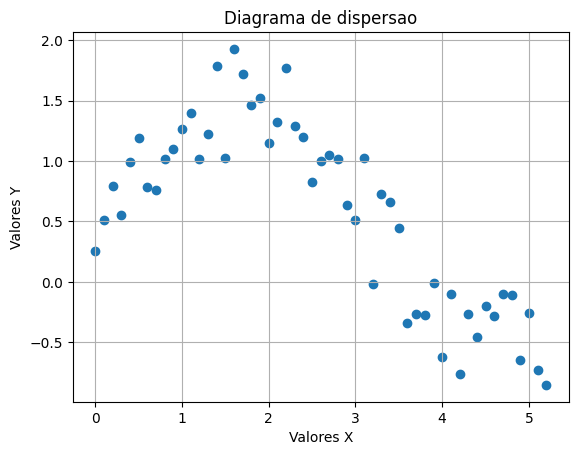

In [70]:
data = retorna_dados(r'data_preg.csv')
dados = data.values.tolist()
vetor_x, vetor_y = gera_vetores(dados)
gera_grafico_dispersao(vetor_x, vetor_y, label_x="Valores X", label_y="Valores Y")

 c) Use a função polyfit para gerar a linha de regressão para N = 1 e
        trace-o no gráfico de dispersão na cor vermelha (plot (x, y, 'r')).
        (Observe que nesta função a numeração coeficiente é invertida! β0=βN , β1=βN−1 , β2=βN−2 , ...βN=β0)

β0 = 1.5179, β1 = -0.3612


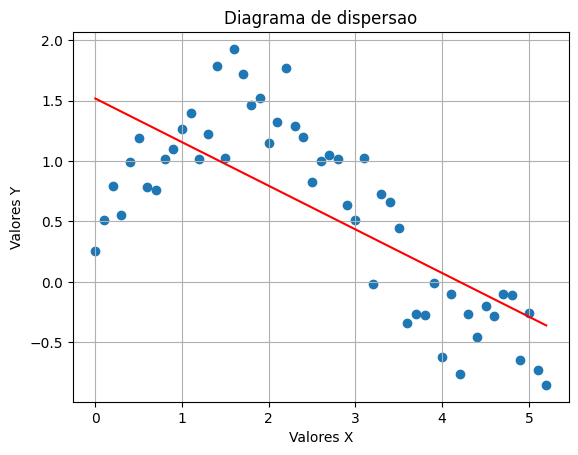

In [71]:
coef1 = np.polyfit(vetor_x, vetor_y, 1)
print(f"β0 = {coef1[1]:.4f}, β1 = {coef1[0]:.4f}")
gera_grafico_dispersao(vetor_x, vetor_y, "Valores X", "Valores Y", regressoes=[(coef1, 'r')])

  d) Trace a linha de regressão para N = 2 no gráfico na cor verde.
  Para isso, você deverá calcular esta função y = 𝛽0 + 𝛽1X + 𝛽2X2 + 𝛽3X3 + …+ 𝛽 NXN,
  isto é, não pode usar a função pronta do python

β0 = 0.7636, β1 = 0.5261, β2 = -0.1706


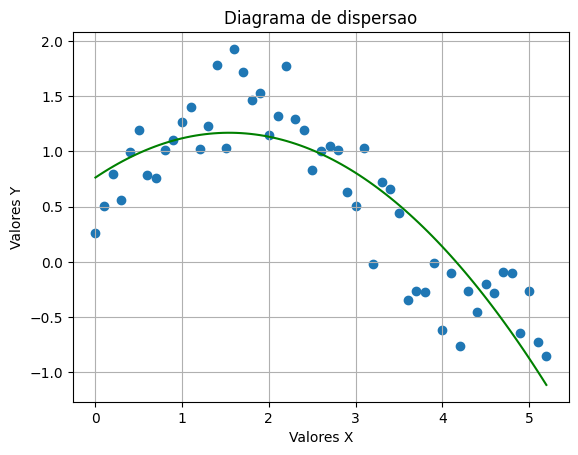

In [72]:
coef2 = np.polyfit(vetor_x, vetor_y, 2)
print(f"β0 = {coef2[2]:.4f}, β1 = {coef2[1]:.4f}, β2 = {coef2[0]:.4f}")
gera_grafico_dispersao(vetor_x, vetor_y, "Valores X", "Valores Y", regressoes=[(coef2, 'g')])

e) Trace a linha de regressão para N = 3 no gráfico na cor preta.

β0 = 0.1858, β1 = 1.9267, β2 = -0.8504, β3 = 0.0872


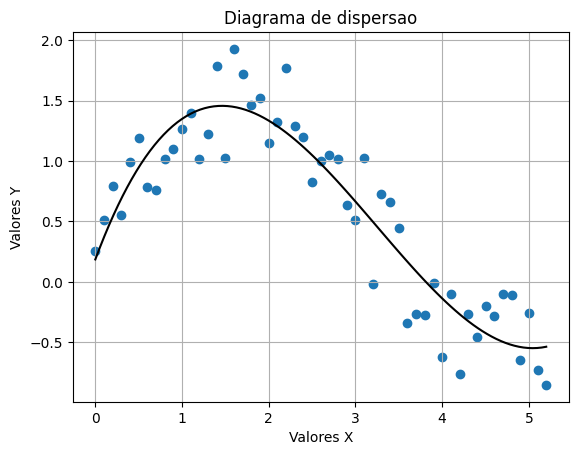

In [73]:
coef3 = np.polyfit(vetor_x, vetor_y, 3)
print(f"β0 = {coef3[3]:.4f}, β1 = {coef3[2]:.4f}, β2 = {coef3[1]:.4f}, β3 = {coef3[0]:.4f}")
gera_grafico_dispersao(vetor_x, vetor_y, "Valores X", "Valores Y", regressoes=[(coef3, 'k')])

f) Trace a linha de regressão para N = 8 no gráfico na cor amarela.

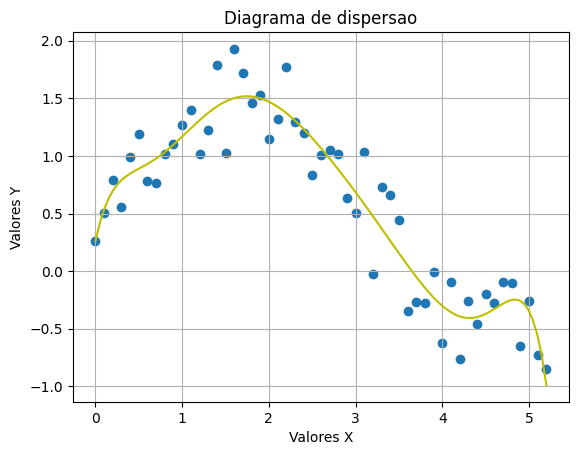

In [74]:
coef8 = np.polyfit(vetor_x, vetor_y, 8)
gera_grafico_dispersao(vetor_x, vetor_y, "Valores X", "Valores Y", regressoes=[(coef8, 'y')])

Visualização dos graficos acima sobrepostos

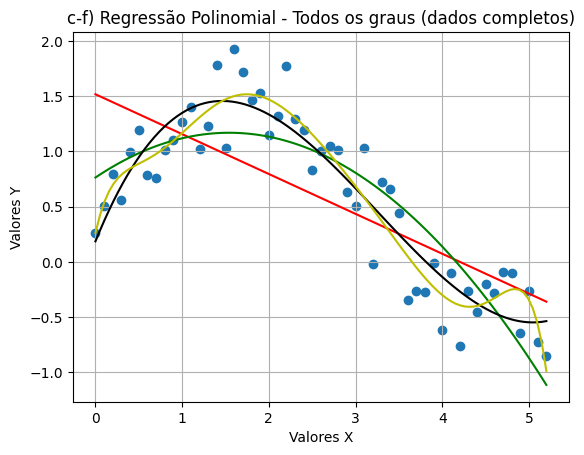

In [75]:
gera_grafico_dispersao(
        vetor_x, vetor_y, "Valores X", "Valores Y",
        titulo="c-f) Regressão Polinomial - Todos os graus (dados completos)",
        regressoes=[(coef1, 'r'), (coef2, 'g'), (coef3, 'k'), (coef8, 'y')],
)

g) Calcule o erro quadratico medio para cada regressao

In [76]:
mse1B = calcula_eqm(vetor_y, coef1, vetor_x)
mse2B = calcula_eqm(vetor_y, coef2, vetor_x)
mse3B = calcula_eqm(vetor_y, coef3, vetor_x)
mse8B = calcula_eqm(vetor_y, coef8, vetor_x)

print(f"\nEQM N=1: {mse1B:.4f}")
print(f"EQM N=2: {mse2B:.4f}")
print(f"EQM N=3: {mse3B:.4f}")
print(f"EQM N=8: {mse8B:.4f}")


EQM N=1: 0.2659
EQM N=2: 0.1385
EQM N=3: 0.0787
EQM N=8: 0.0587


O modelo mais preciso é o de grau 8, pois apresentou o menor valor de Erro Quadrático Médio. Isso indica que ele possui o melhor ajuste aos dados observados.

Entretanto, ao aumentar o grau do polinômio, o modelo se torna mais complexo e pode ocorrer overfitting, ou seja, o modelo passa a se ajustar muito bem aos dados de treinamento, mas pode não generalizar bem para novos dados.

h) Para evitar o overfitting, divida os dados aleatoriamente em Dados de Treinamento
      e Dados de Teste. Use 10% dos dados como conjunto de teste,
      e o resto como de treinamento.

In [77]:
dados_treino, dados_teste = divide_dados(dados, percentual_teste=0.1)
print(f"\nTotal: {len(dados)} | Treino: {len(dados_treino)} | Teste: {len(dados_teste)}")


Total: 53 | Treino: 48 | Teste: 5


i) Repita os passos de c - f, mas agora use apenas os dados de treinamento para ajustar a linha de regressão.


β0 = 1.5642, β1 = -0.3713


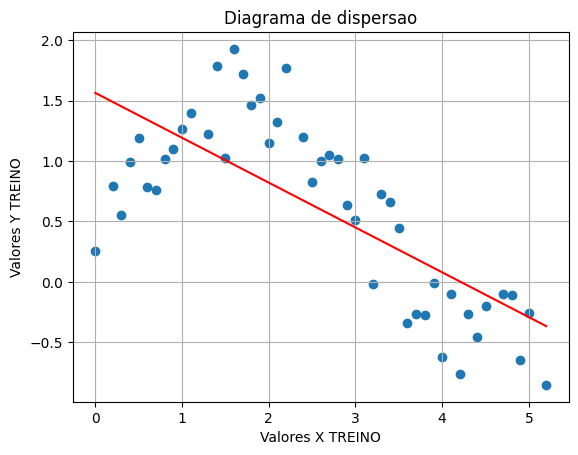

β0 = 0.8108, β1 = 0.5017, β2 = -0.1693


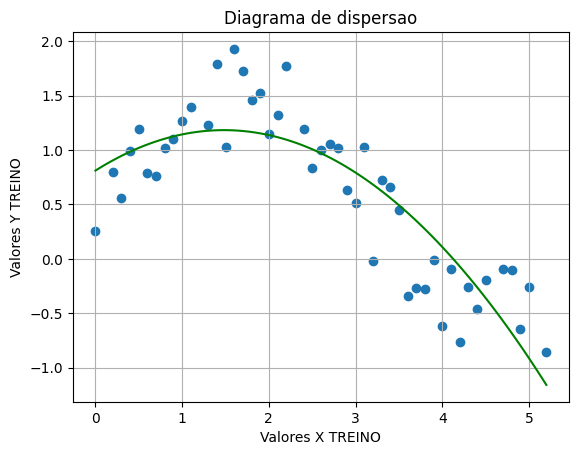

β0 = 0.1333, β1 = 2.0590, β2 = -0.9140, β3 = 0.0953


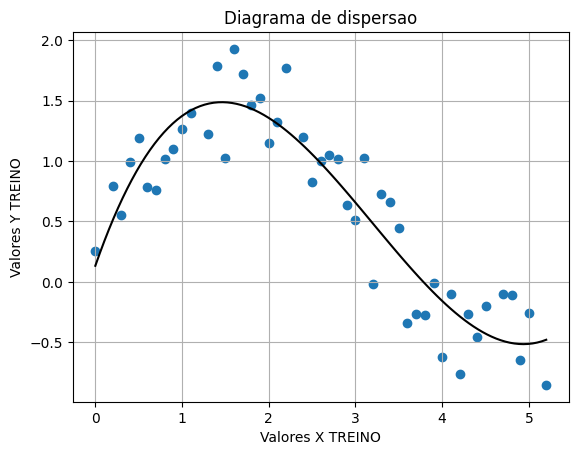

β0 = 0.2815, β1 = 3.3342, β2 = -8.4027, β3 = 11.9385


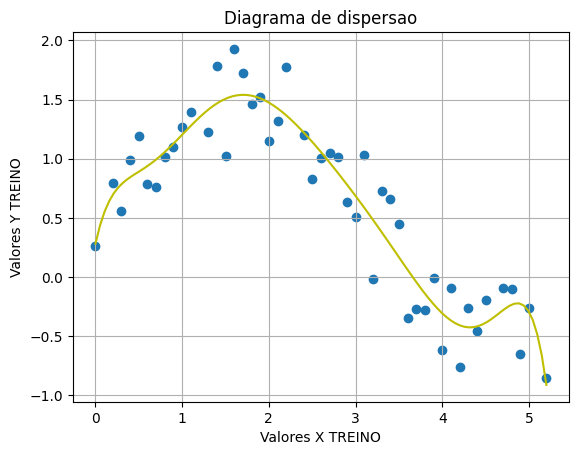

In [78]:
x_treino, y_treino = gera_vetores(dados_treino)

coef1 = np.polyfit(x_treino, y_treino, 1)
print(f"\nβ0 = {coef1[1]:.4f}, β1 = {coef1[0]:.4f}")
gera_grafico_dispersao(x_treino, y_treino, "Valores X TREINO", "Valores Y TREINO", regressoes=[(coef1, 'r')])

coef2 = np.polyfit(x_treino, y_treino, 2)
print(f"β0 = {coef2[2]:.4f}, β1 = {coef2[1]:.4f}, β2 = {coef2[0]:.4f}")
gera_grafico_dispersao(x_treino, y_treino, "Valores X TREINO", "Valores Y TREINO", regressoes=[(coef2, 'g')])

coef3 = np.polyfit(x_treino, y_treino, 3)
print(f"β0 = {coef3[3]:.4f}, β1 = {coef3[2]:.4f}, β2 = {coef3[1]:.4f}, β3 = {coef3[0]:.4f}")
gera_grafico_dispersao(x_treino, y_treino, "Valores X TREINO", "Valores Y TREINO", regressoes=[(coef3, 'k')])

coef8 = np.polyfit(x_treino, y_treino, 8)
print(f"β0 = {coef8[8]:.4f}, β1 = {coef8[7]:.4f}, β2 = {coef8[6]:.4f}, β3 = {coef8[5]:.4f}")
gera_grafico_dispersao(x_treino, y_treino, "Valores X TREINO", "Valores Y TREINO", regressoes=[(coef8, 'y')])

Visualização dos graficos acima sobrepostos

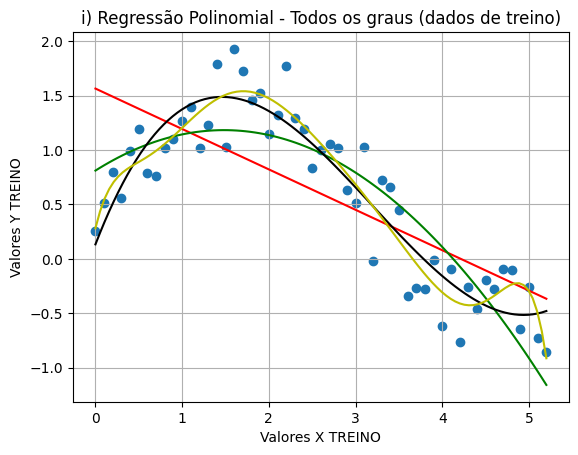

In [79]:
gera_grafico_dispersao(
  vetor_x, vetor_y, "Valores X TREINO", "Valores Y TREINO",
  titulo="i) Regressão Polinomial - Todos os graus (dados de treino)",
  regressoes=[(coef1, 'r'), (coef2, 'g'), (coef3, 'k'), (coef8, 'y')],
)

J) Repita o passo g, mas agora utilize somente os dados de Teste para calcular o erro.

In [80]:
x_teste, y_teste = gera_vetores(dados_teste)

mse1T = calcula_eqm(y_teste, coef1, x_teste)
mse2T = calcula_eqm(y_teste, coef2, x_teste)
mse3T = calcula_eqm(y_teste, coef3, x_teste)
mse8T = calcula_eqm(y_teste, coef8, x_teste)

print(f"\nEQM TESTE N=1: {mse1T:.4f}")
print(f"EQM TESTE N=2: {mse2T:.4f}")
print(f"EQM TESTE N=3: {mse3T:.4f}")
print(f"EQM TESTE N=8: {mse8T:.4f}")



EQM TESTE N=1: 0.3128
EQM TESTE N=2: 0.0647
EQM TESTE N=3: 0.0632
EQM TESTE N=8: 0.0335


  k) Calcule o R² para os dados de treino e teste (sklearn.metrics.r2_score).
  Conclusão: modelos com R² alto no treino mas baixo no teste indicam overfitting.

In [81]:
print("\nR2 - Treino vs Teste:")
for grau, coef in [(1, coef1), (2, coef2), (3, coef3), (8, coef8)]:
    y_pred_treino = calcula_y_regressao(coef, x_treino)
    y_pred_teste = calcula_y_regressao(coef, x_teste)
    r2_treino = r2_score(y_treino, y_pred_treino)
    r2_teste = r2_score(y_teste, y_pred_teste)
    print(f"\n N={grau}: R2 treino={r2_treino:.4f}, R2 teste={r2_teste:.4f}")


R2 - Treino vs Teste:

 N=1: R2 treino=0.5364, R2 teste=0.4637

 N=2: R2 treino=0.7396, R2 teste=0.8890

 N=3: R2 treino=0.8567, R2 teste=0.8916

 N=8: R2 treino=0.8903, R2 teste=0.9426


O modelo com N = 8 apresentou o melhor resultado geral, pois obteve o maior R² no teste, indicando maior capacidade de generalização.

Isso mostra que escolher o grau do polinômio é essencial para evitar underfitting e overfitting.

  l) Visto o cálculo do erro e do coeficiente de determinação, qual o modelo mais preciso neste caso? Explique sua resposta.
  R: O modelo mais preciso é aquele que apresenta menor EQM e maior R2 nos dados de teste,
  por conta da generalização e não memorização.
  Mesmo que N=8 tenha o menor EQM de treinamento nos dados de teste ele tende a ter EQM maior e R2 menor do que N=2 ou N=3,
  indicando overfitting. Portanto, o modelo de grau 3 costuma ser o mais
  preciso neste caso: equilibra bem o ajuste aos dados sem decorar ruídos,
  resultando no melhor desempenho de generalização

m) Trace a curva de regressão polinomial de grau 20 no gráfico de dispersão dos dados.
        Compare o comportamento desta curva com os modelos de grau 1, 2, 3 e 8 e analise o erro quadrático médio (EQM)
        nos dados de treinamento e nos dados de teste.
        O modelo de grau 20 apresenta melhor desempenho nos dados de teste?
        O que acontece com a forma da curva?
        Justifique sua resposta.


/tmp/ipykernel_6194/2702163323.py:1: RankWarning: Polyfit may be poorly conditioned
  coef20 = np.polyfit(x_treino, y_treino, 20)


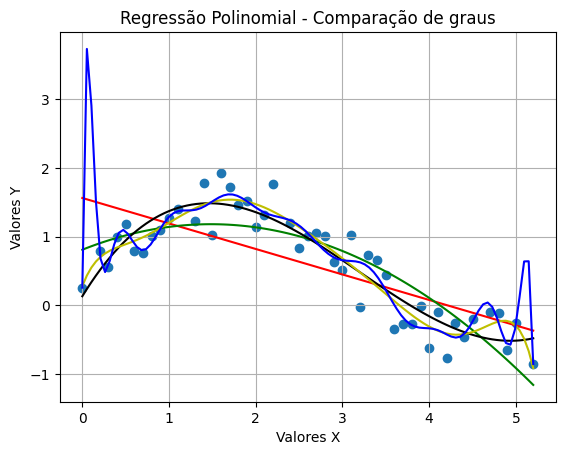


EQM - Treino vs Teste (letra m):
  N= 1: EQM treino=0.2618, EQM teste=0.3128
  N= 2: EQM treino=0.1470, EQM teste=0.0647
  N= 3: EQM treino=0.0809, EQM teste=0.0632
  N= 8: EQM treino=0.0619, EQM teste=0.0335
  N=20: EQM treino=0.0492, EQM teste=1.7204


In [82]:
coef20 = np.polyfit(x_treino, y_treino, 20)
gera_grafico_dispersao(
    x_treino, y_treino, "Valores X", "Valores Y",
    titulo="Regressão Polinomial - Comparação de graus",
    regressoes=[
        (coef1, 'r'),
        (coef2, 'g'),
        (coef3, 'k'),
        (coef8, 'y'),
        (coef20, 'b'),
    ]
)

mse20_treino = calcula_eqm(y_treino, coef20, x_treino)
mse20_teste  = calcula_eqm(y_teste,  coef20, x_teste)

print("\nEQM - Treino vs Teste (letra m):")
for grau, coef in [(1, coef1), (2, coef2), (3, coef3), (8, coef8), (20, coef20)]:
    eqm_treino = calcula_eqm(y_treino, coef, x_treino)
    eqm_teste  = calcula_eqm(y_teste,  coef, x_teste)
    print(f"  N={grau:2d}: EQM treino={eqm_treino:.4f}, EQM teste={eqm_teste:.4f}")

  O modelo de grau 20 apresenta EQM muito baixo nos dados de treinamento,
  pois praticamente memoriza os pontos (overfitting). Porém, nos dados
  de teste o EQM tende a ser muito alto, pior do que modelos de menor grau.
  A curva de grau 20 oscila violentamente entre os pontos de treino,
  perdendo toda capacidade de generalização. Modelos de grau 3
  costuma equilibrar melhor viés e variância, resultando em menor EQM de teste.

In [83]:
    """Comparacao eqm e r2 de base, treino e teste para cada grau de regressao"""
    print("\nComparação EQM e R2 - Base vs Treino vs Teste:")
    for grau, coef, eqm_base in [(1, coef1, mse1B), (2, coef2, mse2B), (3, coef3, mse3B), (8, coef8, mse8B)]:
        eqm_treino = calcula_eqm(y_treino, coef, x_treino)
        eqm_teste  = calcula_eqm(y_teste,  coef, x_teste)
        r2_treino  = r2_score(y_treino, calcula_y_regressao(coef, x_treino))
        r2_teste   = r2_score(y_teste,  calcula_y_regressao(coef, x_teste))
        print(f"N={grau:2d}: EQM BASE={eqm_base:.4f} | EQM TREINO={eqm_treino:.4f} | EQM TESTE={eqm_teste:.4f} | \nR2 TREINO={r2_treino:.4f} | R2 TESTE={r2_teste:.4f}\n")

    r2_20_treino = r2_score(y_treino, calcula_y_regressao(coef20, x_treino))
    r2_20_teste  = r2_score(y_teste,  calcula_y_regressao(coef20, x_teste))
    print(f"N=20: EQM BASE=  N/A  | EQM TREINO={mse20_treino:.4f} | EQM TESTE={mse20_teste:.4f} | \nR2 TREINO={r2_20_treino:.4f} | R2 TESTE={r2_20_teste:.4f}\n")


Comparação EQM e R2 - Base vs Treino vs Teste:
N= 1: EQM BASE=0.2659 | EQM TREINO=0.2618 | EQM TESTE=0.3128 | 
R2 TREINO=0.5364 | R2 TESTE=0.4637

N= 2: EQM BASE=0.1385 | EQM TREINO=0.1470 | EQM TESTE=0.0647 | 
R2 TREINO=0.7396 | R2 TESTE=0.8890

N= 3: EQM BASE=0.0787 | EQM TREINO=0.0809 | EQM TESTE=0.0632 | 
R2 TREINO=0.8567 | R2 TESTE=0.8916

N= 8: EQM BASE=0.0587 | EQM TREINO=0.0619 | EQM TESTE=0.0335 | 
R2 TREINO=0.8903 | R2 TESTE=0.9426

N=20: EQM BASE=  N/A  | EQM TREINO=0.0492 | EQM TESTE=1.7204 | 
R2 TREINO=0.9128 | R2 TESTE=-1.9503

